# Data Cleaning and Preprocessing

## Objective

The objective of this project is to demonstrate professional data cleaning
skills by identifying and resolving missing values, duplicate records,
inconsistent formatting, outliers, incorrect data types, and other data
quality issues.

## Technologies Used

- Python
- Pandas
- NumPy
- Jupyter Notebook / Google Colab

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/retail_store_sales-selected-columns task 3.csv')

# Display first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe(include='all').T)

Dataset Shape: (12575, 10)

Column Names:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']

Data Types:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object

Missing Values:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
dtype: int64

Duplicate Rows: 0

Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,12575,12575,TXN_2407494,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,12575,25,CUST_05,544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,12575,8,Electric household essentials,1591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,11362,200,Item_2_BEV,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price Per Unit,11966.0,NaN,NaN,NaN,23.365912,10.743519,5.0,14.0,23.0,33.5,41.0
Quantity,11971.0,NaN,NaN,NaN,5.53638,2.857883,1.0,3.0,6.0,8.0,10.0
Total Spent,11971.0,NaN,NaN,NaN,129.652577,94.750697,5.0,51.0,108.5,192.0,410.0
Payment Method,12575,3,Cash,4310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,12575,2,Online,6354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction Date,12575,1114,2022-05-30,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].dropna().unique()[:30])


--- Transaction ID ---
Unique values: 12575
['TXN_6867343' 'TXN_3731986' 'TXN_9303719' 'TXN_9458126' 'TXN_4575373'
 'TXN_7482416' 'TXN_3652209' 'TXN_1372952' 'TXN_9728486' 'TXN_2722661'
 'TXN_8776416' 'TXN_5422631' 'TXN_5874772' 'TXN_4413070' 'TXN_2490363'
 'TXN_1809665' 'TXN_7563311' 'TXN_9634894' 'TXN_4396807' 'TXN_4206593'
 'TXN_9939063' 'TXN_8685338' 'TXN_6547964' 'TXN_3314099' 'TXN_9980736'
 'TXN_3481599' 'TXN_9057609' 'TXN_1599706' 'TXN_1598860' 'TXN_7138501']

--- Customer ID ---
Unique values: 25
['CUST_09' 'CUST_22' 'CUST_02' 'CUST_06' 'CUST_05' 'CUST_07' 'CUST_21'
 'CUST_23' 'CUST_25' 'CUST_14' 'CUST_15' 'CUST_17' 'CUST_01' 'CUST_10'
 'CUST_04' 'CUST_13' 'CUST_18' 'CUST_08' 'CUST_20' 'CUST_12' 'CUST_11'
 'CUST_19' 'CUST_16' 'CUST_24' 'CUST_03']

--- Category ---
Unique values: 8
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']

--- Item ---
Unique values: 200
['Item_10_PAT' 'Item_17

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    print(f"\n--- {col} ---")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())


--- Price Per Unit ---
Minimum: 5.0
Maximum: 41.0
Mean: 23.365911749958215
Median: 23.0

--- Quantity ---
Minimum: 1.0
Maximum: 10.0
Mean: 5.536379583994654
Median: 6.0

--- Total Spent ---
Minimum: 5.0
Maximum: 410.0
Mean: 129.6525770612313
Median: 108.5


In [ ]:
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])

In [ ]:
numeric_missing = ['Price Per Unit', 'Quantity', 'Total Spent']

for col in numeric_missing:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicate_count)

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: x.title() if isinstance(x, str) else x)

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].dropna().unique()[:20])


Transaction ID:
['Txn_6867343' 'Txn_3731986' 'Txn_9303719' 'Txn_9458126' 'Txn_4575373'
 'Txn_7482416' 'Txn_3652209' 'Txn_1372952' 'Txn_9728486' 'Txn_2722661'
 'Txn_8776416' 'Txn_5422631' 'Txn_5874772' 'Txn_4413070' 'Txn_2490363'
 'Txn_1809665' 'Txn_7563311' 'Txn_9634894' 'Txn_4396807' 'Txn_4206593']

Customer ID:
['Cust_09' 'Cust_22' 'Cust_02' 'Cust_06' 'Cust_05' 'Cust_07' 'Cust_21'
 'Cust_23' 'Cust_25' 'Cust_14' 'Cust_15' 'Cust_17' 'Cust_01' 'Cust_10'
 'Cust_04' 'Cust_13' 'Cust_18' 'Cust_08' 'Cust_20' 'Cust_12']

Category:
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric Household Essentials' 'Computers And Electric Accessories']

Item:
['Item_10_Pat' 'Item_17_Milk' 'Item_12_But' 'Item_16_Bev' 'Item_6_Food'
 'Item_2_Bev' 'Item_1_Food' 'Item_16_Fur' 'Item_22_But' 'Item_3_But'
 'Item_2_Food' 'Item_24_Pat' 'Item_16_Milk' 'Item_17_Pat' 'Item_13_Ehe'
 'Item_7_Bev' 'Item_4_Ehe' 'Item_10_Food' 'Item_14_Fur' 'Item_20_But']

Payment Method:
['Digital Wallet' 

In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
df['Transaction Date'] = pd.to_datetime(
    df['Transaction Date'],
    errors='coerce'
)

In [ ]:
df['Price Per Unit'] = pd.to_numeric(
    df['Price Per Unit'],
    errors='coerce'
)

df['Quantity'] = pd.to_numeric(
    df['Quantity'],
    errors='coerce'
)

df['Total Spent'] = pd.to_numeric(
    df['Total Spent'],
    errors='coerce'
)

In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]


In [ ]:
print("Missing values after type conversion:")
print(df.isnull().sum())

Missing values after type conversion:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [ ]:
for col in ['Price Per Unit', 'Quantity', 'Total Spent']:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df['Transaction Date'] = df['Transaction Date'].fillna(
    df['Transaction Date'].mode()[0]
)

In [ ]:
numeric_columns = ['Price Per Unit', 'Quantity', 'Total Spent']

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}:")
    print("Number of outliers:", len(outliers))
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print()

Price Per Unit:
Number of outliers: 0
Lower Bound: -13.0
Upper Bound: 59.0

Quantity:
Number of outliers: 0
Lower Bound: -4.5
Upper Bound: 15.5

Total Spent:
Number of outliers: 157
Lower Bound: -138.5
Upper Bound: 377.5



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

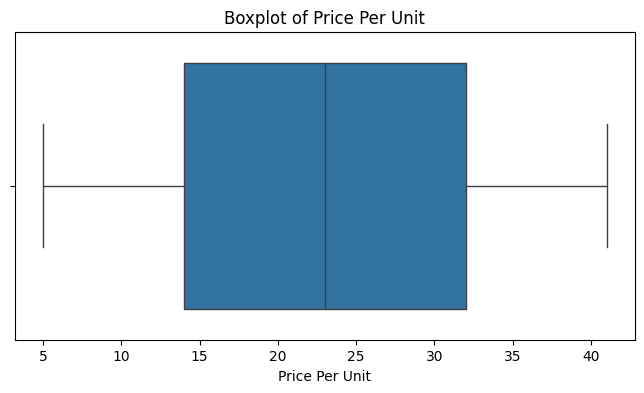

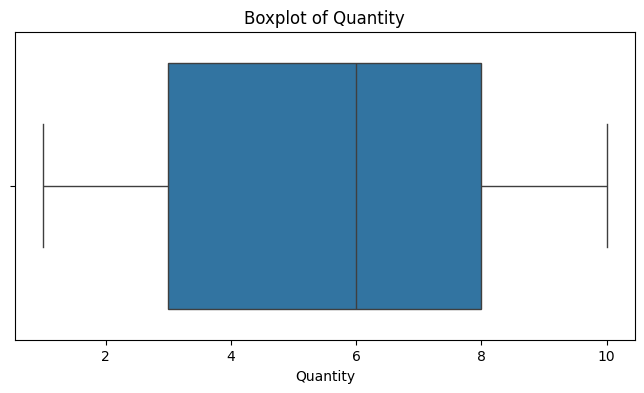

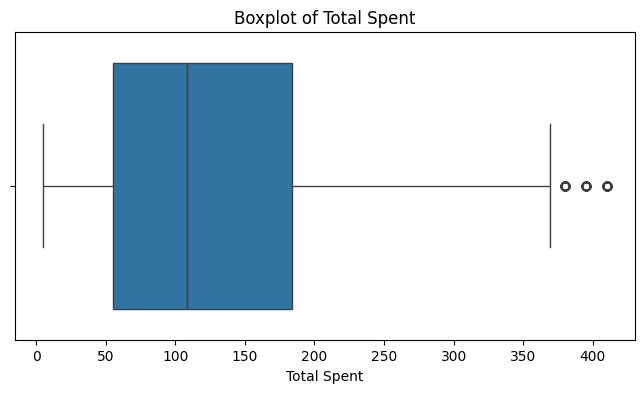

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [ ]:
print("===== FINAL DATA QUALITY REPORT =====")

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

===== FINAL DATA QUALITY REPORT =====

Number of Rows: 12575
Number of Columns: 10

Missing Values:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Duplicate Rows: 0

Data Types:
Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object


In [ ]:
print("Final Shape:", df.shape)

Final Shape: (12575, 10)


In [ ]:
quality_report = pd.DataFrame({
    'Metric': [
        'Number of Rows',
        'Number of Columns',
        'Missing Values',
        'Duplicate Rows'
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

display(quality_report)

,Metric,After Cleaning
0,Number of Rows,12575
1,Number of Columns,10
2,Missing Values,0
3,Duplicate Rows,0


In [ ]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,Txn_6867343,Cust_09,Patisserie,Item_10_Pat,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08
1,Txn_3731986,Cust_22,Milk Products,Item_17_Milk,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,Txn_9303719,Cust_02,Butchers,Item_12_But,21.5,2.0,43.0,Credit Card,Online,2022-10-05
3,Txn_9458126,Cust_06,Beverages,Item_16_Bev,27.5,9.0,247.5,Credit Card,Online,2022-05-07
4,Txn_4575373,Cust_05,Food,Item_6_Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02
5,Txn_7482416,Cust_09,Patisserie,Item_2_Bev,23.0,10.0,200.0,Credit Card,Online,2023-11-30
6,Txn_3652209,Cust_07,Food,Item_1_Food,5.0,8.0,40.0,Credit Card,In-Store,2023-06-10
7,Txn_1372952,Cust_21,Furniture,Item_2_Bev,33.5,6.0,108.5,Digital Wallet,In-Store,2024-04-02
8,Txn_9728486,Cust_23,Furniture,Item_16_Fur,27.5,1.0,27.5,Credit Card,In-Store,2023-04-26
9,Txn_2722661,Cust_25,Butchers,Item_22_But,36.5,3.0,109.5,Cash,Online,2024-03-14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 982.6+ KB


In [ ]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.348191,5.558648,128.415706,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,55.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00
75%,32.000000,8.000000,184.000000,2024-04-24 00:00:00
max,41.000000,10.000000,377.500000,2025-01-18 00:00:00
std,10.480413,2.790160,91.928744,NaN


In [ ]:
output_file = '/content/Shivendra_Task3_Cleaned_Retail_Sales.csv'

df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")
print(output_file)

Cleaned dataset saved successfully!
/content/Shivendra_Task3_Cleaned_Retail_Sales.csv


In [ ]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

The retail sales dataset was successfully cleaned and prepared for further analysis.

The data cleaning process included a detailed quality assessment, missing-value treatment, duplicate checking, text-format standardization, data type correction, and outlier detection using the IQR method.

Missing categorical values were handled using the mode, while missing numerical values were replaced using the median. No duplicate records were found. Numerical outliers were capped instead of removed to preserve potentially valid retail transactions.

The final dataset has improved consistency, appropriate data types, and better data quality, making it suitable for further analysis and visualization.